# 作業 1：資料前處理、特徵選擇與 Titanic 生存預測

本作業使用 `titanic.csv` 練習分類任務中的資料前處理與特徵分析。

請將 `titanic.csv` 與本 Notebook 放在同一個資料夾中，再依序執行每個程式區塊。

---

## 本作業學習重點

本作業是根據課堂教材 `1.ipynb` 簡化而來。原教材中的同類型方法很多，本作業每一類只選一個代表方法練習，讓學生先掌握完整流程。

你會練習：

1. 讀取資料與觀察欄位
2. 區分數值型資料與類別型資料
3. 理解 `fit`、`transform`、`fit_transform`
4. 數值型資料標準化：使用 `StandardScaler`
5. 類別型資料編碼：使用 `pd.get_dummies()` 做 One-Hot Encoding
6. 遺漏值處理：使用 `SimpleImputer`
7. 離群值檢查與處理：使用 IQR 法
8. 切割訓練集與測試集
9. 建立簡單分類模型：Logistic Regression
10. 使用一個評估指標：Accuracy
11. 使用混淆矩陣視覺化分類結果
12. 使用 K-fold 交叉驗證
13. 特徵選擇：低變異過濾、相關係數、ANOVA F-test
14. 特徵重要性：Permutation Importance

---

## 注意事項

本作業刻意採用較簡單的寫法：

- 不使用 `Pipeline`
- 不使用 list comprehension
- 同類型方法只選一個代表做法
- 程式碼以初學者容易閱讀為主
- 需要檢查結果的地方會加入視覺化

## 0. 匯入套件與設定圖表

這一段負責匯入常用套件，並設定中文字型，讓圖表可以正常顯示中文。

In [ ]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 設定字型 (有內建微軟正黑體)
import matplotlib.pyplot as plt

# 設定繪圖風格與字型，確保中文顯示正常
plt.style.use('fivethirtyeight')

# 設定字型為微軟正黑體，並確保數學符號正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 確保負號和數學符號正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

In [1]:
# ============================================================
# 0. 匯入套件與設定圖表
# ============================================================

# 忽略警告訊息，避免畫面太雜亂
import warnings
warnings.filterwarnings("ignore")

# 基本資料處理套件
import numpy as np
import pandas as pd

# 視覺化套件
import matplotlib.pyplot as plt

# 資料前處理工具
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 資料切分與交叉驗證
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# 分類模型
from sklearn.linear_model import LogisticRegression

# 評估與視覺化
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

# 特徵選擇與特徵重要性
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance

# 設定圖表大小
plt.rcParams["figure.figsize"] = (8, 5)

# 設定中文字型
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 讓負號可以正常顯示
plt.rcParams["axes.unicode_minus"] = False

## 1. 讀取資料與欄位說明

Titanic 資料集常用來練習二元分類任務，目標是預測乘客是否生還。

| 欄位名稱 | 說明 |
|---|---|
| `PassengerId` | 乘客編號 |
| `Survived` | 是否生還，`1` 表示生還，`0` 表示未生還 |
| `Pclass` | 船票艙等，`1`、`2`、`3` 分別代表不同艙等 |
| `Name` | 乘客姓名 |
| `Sex` | 性別 |
| `Age` | 年齡 |
| `SibSp` | 同船的兄弟姊妹或配偶數量 |
| `Parch` | 同船的父母或子女數量 |
| `Ticket` | 船票號碼 |
| `Fare` | 票價 |
| `Cabin` | 艙房號碼 |
| `Embarked` | 登船港口 |

In [2]:
# 讀取 Titanic 資料
# 請確認 titanic.csv 與本 Notebook 放在同一個資料夾中

df = pd.read_csv("titanic.csv")

# 顯示前 5 筆資料
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 查看資料筆數與欄位數
df.shape

(891, 12)

In [4]:
# 查看每個欄位的資料型態與非空值數量
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# 查看數值型欄位的基本統計資訊
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 作業問題 1

請回答：

1. 這份資料共有幾筆資料？
2. 目標變數是哪一個欄位？
3. `Survived = 1` 與 `Survived = 0` 分別代表什麼意思？

## 2. 初步資料視覺化

建模前，先用圖表觀察目標變數與重要欄位。

本節會觀察：

1. 生還與未生還人數
2. 年齡分布
3. 性別與生還率的關係

Survived
0    549
1    342
Name: count, dtype: int64


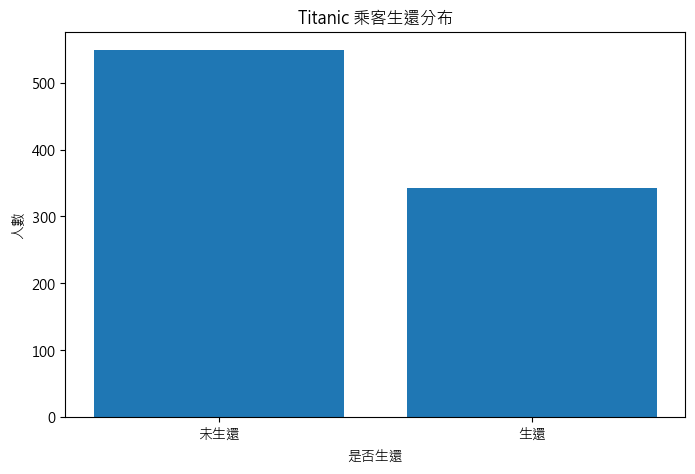

In [6]:
# ============================================================
# 觀察目標變數：Survived
# ============================================================

survived_count = df["Survived"].value_counts().sort_index()
print(survived_count)

plt.bar(["未生還", "生還"], survived_count.values)
plt.xlabel("是否生還")
plt.ylabel("人數")
plt.title("Titanic 乘客生還分布")
plt.show()

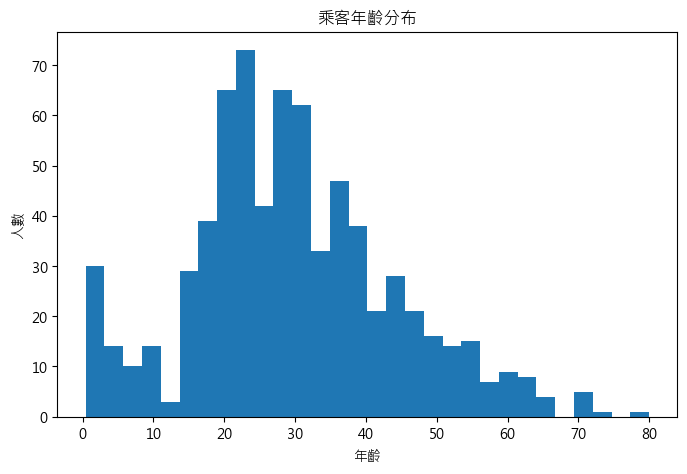

In [7]:
# ============================================================
# 觀察年齡分布
# ============================================================

plt.hist(df["Age"].dropna(), bins=30)
plt.xlabel("年齡")
plt.ylabel("人數")
plt.title("乘客年齡分布")
plt.show()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


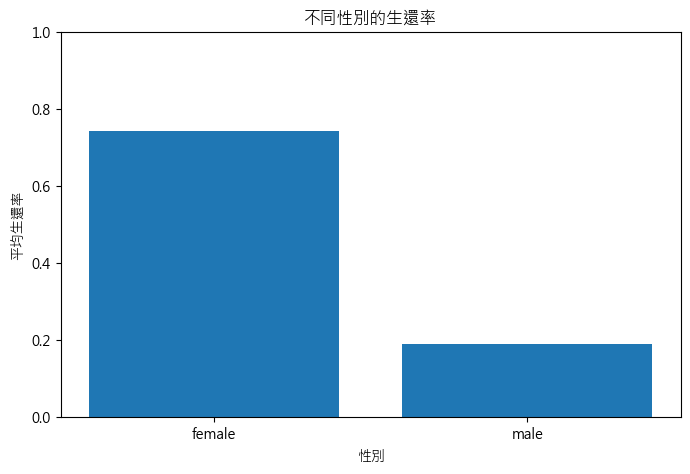

In [8]:
# ============================================================
# 觀察性別與生還率的關係
# ============================================================

sex_survival_rate = df.groupby("Sex")["Survived"].mean()
print(sex_survival_rate)

plt.bar(sex_survival_rate.index, sex_survival_rate.values)
plt.xlabel("性別")
plt.ylabel("平均生還率")
plt.title("不同性別的生還率")
plt.ylim(0, 1)
plt.show()

### 作業問題 2

請觀察上方圖表並回答：

1. 生還與未生還的人數是否平均？
2. 年齡欄位是否有遺漏值？你從哪裡看出來？
3. 性別看起來是否與生還率有關？

## 3. 數值型資料與類別型資料

機器學習模型通常需要數值型輸入，所以我們需要先知道哪些欄位是數值型、哪些欄位是類別型。

在本資料中：

- 數值型欄位：例如 `Age`、`Fare`、`SibSp`、`Parch`
- 類別型欄位：例如 `Sex`、`Embarked`

注意：`Pclass` 雖然是數字，但它其實表示艙等類別。為了簡化作業，本作業先把它當成可直接使用的數值特徵。

In [9]:
# 取出數值型欄位
numeric_columns = df.select_dtypes(include="number").columns
print("數值型欄位：")
print(numeric_columns)

# 取出非數值型欄位
category_columns = df.select_dtypes(exclude="number").columns
print("\n非數值型欄位：")
print(category_columns)

數值型欄位：
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

非數值型欄位：
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')


### 作業問題 3

請回答：

1. `Age` 是數值型還是類別型？
2. `Sex` 是數值型還是類別型？
3. 為什麼類別型欄位通常不能直接丟進機器學習模型？

## 4. 遺漏值檢查與填補

遺漏值是資料前處理中非常常見的問題。

本作業使用 `SimpleImputer`：

- 數值型欄位 `Age`：使用中位數填補
- 類別型欄位 `Embarked`：使用眾數填補
- `Cabin` 遺漏太多，本作業不直接使用原始 `Cabin`，改建立 `HasCabin` 表示是否有艙房資料

原教材中還有 `KNNImputer`，但本作業為了簡化，只使用 `SimpleImputer`。

In [10]:
# ============================================================
# 檢查每個欄位的遺漏值數量與比例
# ============================================================

missing_table = pd.DataFrame()
missing_table["missing_count"] = df.isna().sum()
missing_table["missing_ratio"] = df.isna().mean()
missing_table

,missing_count,missing_ratio
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,0.198653
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


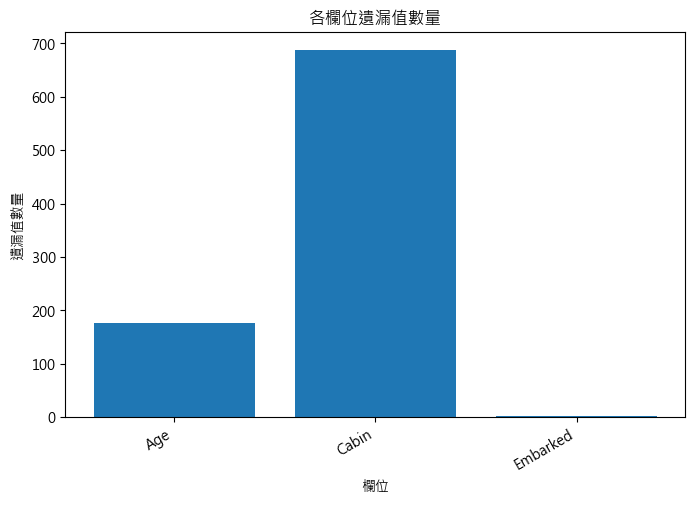

In [11]:
# ============================================================
# 視覺化：只顯示有遺漏值的欄位
# ============================================================

missing_nonzero = missing_table[missing_table["missing_count"] > 0]

plt.bar(missing_nonzero.index, missing_nonzero["missing_count"])
plt.xlabel("欄位")
plt.ylabel("遺漏值數量")
plt.title("各欄位遺漏值數量")
plt.xticks(rotation=30, ha="right")
plt.show()

In [12]:
# ============================================================
# 使用 SimpleImputer 填補遺漏值
# ============================================================

# 複製一份資料，避免直接修改原始 df
df_clean = df.copy()

# 1. Cabin 遺漏很多，因此改建立 HasCabin 特徵
# HasCabin = 1：原本有 Cabin 資料
# HasCabin = 0：原本沒有 Cabin 資料
df_clean["HasCabin"] = 1
df_clean.loc[df_clean["Cabin"].isna(), "HasCabin"] = 0

# 2. Age 使用中位數填補
age_imputer = SimpleImputer(strategy="median")
df_clean[["Age"]] = age_imputer.fit_transform(df_clean[["Age"]])

# 3. Embarked 使用眾數填補
embarked_imputer = SimpleImputer(strategy="most_frequent")
df_clean[["Embarked"]] = embarked_imputer.fit_transform(df_clean[["Embarked"]])

# 檢查填補後的 Age、Embarked、HasCabin
df_clean[["Age", "Embarked", "HasCabin"]].head()

,Age,Embarked,HasCabin
0,22.0,S,0
1,38.0,C,1
2,26.0,S,0
3,35.0,S,1
4,35.0,S,0


In [13]:
# 檢查填補後是否還有遺漏值
check_columns = ["Age", "Embarked", "HasCabin"]
df_clean[check_columns].isna().sum()

Age         0
Embarked    0
HasCabin    0
dtype: int64

### 作業問題 4

請回答：

1. 哪些欄位有遺漏值？
2. 為什麼 `Age` 適合用中位數填補？
3. 為什麼 `Cabin` 不直接用眾數填補，而是改成 `HasCabin`？

## 5. `fit`、`transform`、`fit_transform` 的概念

在 scikit-learn 中，常見三個動作：

| 方法 | 概念 |
|---|---|
| `fit()` | 從訓練資料學習需要的參數，例如平均值、中位數、標準差 |
| `transform()` | 使用已經學到的參數轉換資料 |
| `fit_transform()` | 先 `fit()` 再 `transform()` |

正式建模時，應該只用訓練資料 `fit()`，測試資料只能用同一個物件 `transform()`。

本節先用 `Age` 和 `Fare` 示範標準化概念。

In [14]:
# ============================================================
# 示範 StandardScaler 的 fit 與 transform
# ============================================================

# 只取出兩個欄位做示範
X_demo = df_clean[["Age", "Fare"]]

# 建立標準化器
scaler_demo = StandardScaler()

# fit：學習 Age 與 Fare 的平均值、標準差
scaler_demo.fit(X_demo)

print("平均值：")
print(scaler_demo.mean_)

print("\n標準差：")
print(scaler_demo.scale_)

# transform：使用剛剛學到的平均值與標準差轉換資料
X_demo_scaled = scaler_demo.transform(X_demo)

# 轉回 DataFrame，方便觀看
X_demo_scaled_df = pd.DataFrame(
    X_demo_scaled,
    columns=["Age_scaled", "Fare_scaled"]
)

X_demo_scaled_df.head()

平均值：
[29.36158249 32.20420797]

標準差：
[13.01238827 49.66553444]


,Age_scaled,Fare_scaled
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


In [15]:
# 標準化後，整體平均值會接近 0，標準差會接近 1
print("標準化後的平均值：")
print(X_demo_scaled_df.mean())

print("\n標準化後的標準差：")
print(X_demo_scaled_df.std())

標準化後的平均值：
Age_scaled     2.272780e-16
Fare_scaled    3.987333e-18
dtype: float64

標準化後的標準差：
Age_scaled     1.000562
Fare_scaled    1.000562
dtype: float64


### 作業問題 5

請回答：

1. `fit()` 在 StandardScaler 中學到什麼？
2. `transform()` 是做什麼？
3. 為什麼測試資料不能重新 `fit()`？

## 6. 類別型資料編碼：One-Hot Encoding

機器學習模型通常不能直接處理文字類別，例如 `Sex = male/female`、`Embarked = S/C/Q`。

因此要把類別型欄位轉成 0/1 特徵。

原教材中提到：

- `OneHotEncoder`
- `LabelBinarizer`
- `LabelEncoder`

本作業為了簡化，使用 Pandas 的 `pd.get_dummies()` 做 One-Hot Encoding。

In [16]:
# ============================================================
# 選擇本作業會使用的特徵
# ============================================================

feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "HasCabin"
]

X_raw = df_clean[feature_columns]
y = df_clean["Survived"]

X_raw.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,0
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [17]:
# ============================================================
# 使用 pd.get_dummies() 進行 One-Hot Encoding
# ============================================================

X_encoded = pd.get_dummies(
    X_raw,
    columns=["Sex", "Embarked"],
    dtype=int
)

X_encoded.head()

,Pclass,Age,SibSp,Parch,Fare,HasCabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,1,0,1,0,0
2,3,26.0,0,0,7.9250,0,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,0,1,0,0,1


In [18]:
# 查看編碼後的欄位名稱
X_encoded.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='str')

### 作業問題 6

請回答：

1. `Sex` 被轉換成哪些欄位？
2. `Embarked` 被轉換成哪些欄位？
3. One-Hot Encoding 為什麼適合用在沒有大小順序的類別？

## 7. 離群值檢查與處理：IQR 法

離群值是指和大多數資料差異很大的資料點。

原教材中提到多種方法，例如：

- Elliptic Envelope
- IQR
- Isolation Forest
- Local Outlier Factor
- One-Class SVM

本作業只使用最容易理解的 IQR 法，並以 `Fare` 票價為例。

IQR 公式如下：

$$
IQR = Q3 - Q1
$$

$$
lower = Q1 - 1.5 \times IQR
$$

$$
upper = Q3 + 1.5 \times IQR
$$

小於下界或大於上界的資料，會被視為離群值。

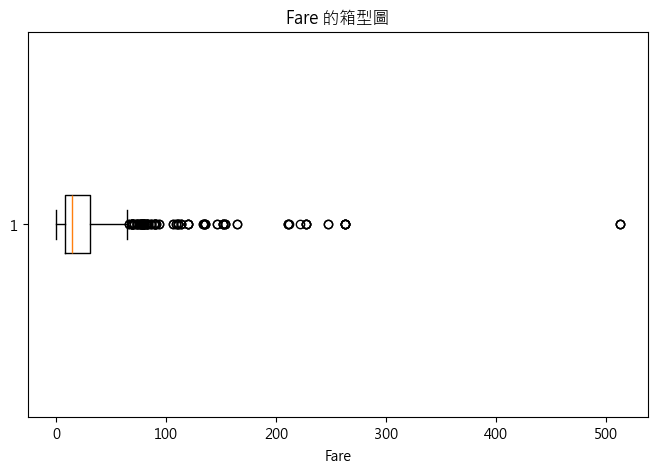

In [19]:
# ============================================================
# 使用箱型圖觀察 Fare 是否有離群值
# ============================================================

plt.boxplot(df_clean["Fare"], vert=False)
plt.xlabel("Fare")
plt.title("Fare 的箱型圖")
plt.show()

In [20]:
# ============================================================
# 使用 IQR 法計算 Fare 的離群值邊界
# ============================================================

q1 = df_clean["Fare"].quantile(0.25)
q3 = df_clean["Fare"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1：", q1)
print("Q3：", q3)
print("IQR：", iqr)
print("下界：", lower_bound)
print("上界：", upper_bound)

fare_outliers = df_clean[
    (df_clean["Fare"] < lower_bound) | (df_clean["Fare"] > upper_bound)
]

print("Fare 離群值筆數：", fare_outliers.shape[0])
fare_outliers[["PassengerId", "Survived", "Pclass", "Fare"]].head()

Q1： 7.9104
Q3： 31.0
IQR： 23.0896
下界： -26.724
上界： 65.6344
Fare 離群值筆數： 116


,PassengerId,Survived,Pclass,Fare
1,2,1,1,71.2833
27,28,0,1,263.0000
31,32,1,1,146.5208
34,35,0,1,82.1708
52,53,1,1,76.7292


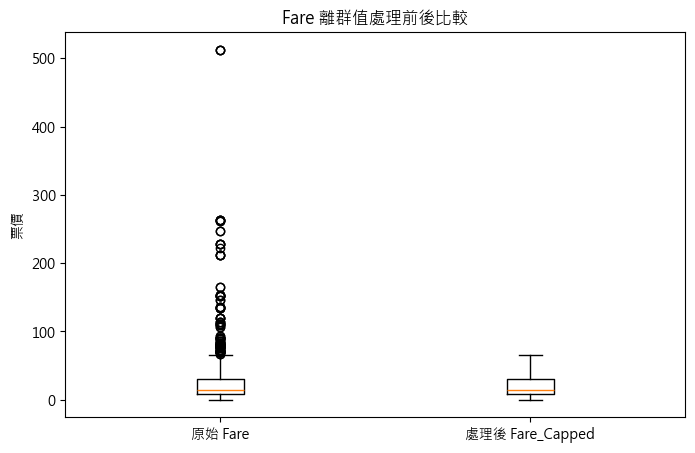

In [21]:
# ============================================================
# 處理離群值：將 Fare 限制在 IQR 邊界內
# ============================================================
# 這種做法稱為 capping，也就是把太大或太小的值限制在邊界上。
# 這裡不刪除資料，是因為 Titanic 資料筆數不算很多。

# 建立新欄位 Fare_Capped，不覆蓋原本的 Fare
df_clean["Fare_Capped"] = df_clean["Fare"]

# 小於下界者，設成下界
df_clean.loc[df_clean["Fare_Capped"] < lower_bound, "Fare_Capped"] = lower_bound

# 大於上界者，設成上界
df_clean.loc[df_clean["Fare_Capped"] > upper_bound, "Fare_Capped"] = upper_bound

# 比較處理前後的箱型圖
plt.boxplot(
    [df_clean["Fare"], df_clean["Fare_Capped"]],
    labels=["原始 Fare", "處理後 Fare_Capped"]
)
plt.ylabel("票價")
plt.title("Fare 離群值處理前後比較")
plt.show()

### 作業問題 7

請回答：

1. `Fare` 是否有明顯離群值？
2. 本作業如何處理 `Fare` 的離群值？
3. 如果直接刪除離群值，可能有什麼問題？

## 8. 建立正式建模資料

接下來建立模型使用的特徵。

注意：本作業使用 `Fare_Capped`，而不是原本的 `Fare`。

In [22]:
# ============================================================
# 建立正式建模資料
# ============================================================

model_feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare_Capped",
    "Embarked",
    "HasCabin"
]

X_model_raw = df_clean[model_feature_columns]
y = df_clean["Survived"]

# One-Hot Encoding
X_model_encoded = pd.get_dummies(
    X_model_raw,
    columns=["Sex", "Embarked"],
    dtype=int
)

X_model_encoded.head()

,Pclass,Age,SibSp,Parch,Fare_Capped,HasCabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,0,1,0,0,1
1,1,38.0,1,0,65.6344,1,1,0,1,0,0
2,3,26.0,0,0,7.9250,0,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,0,1,0,0,1


## 9. 切割訓練集與測試集

建模時通常會把資料切成：

- 訓練集：用來訓練模型
- 測試集：用來評估模型是否能預測沒看過的資料

本作業使用 `train_test_split()`，並設定 `stratify=y`，讓訓練集與測試集中的生還比例接近原始資料。

In [23]:
# ============================================================
# 切割訓練集與測試集
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_model_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train：", X_train.shape)
print("X_test：", X_test.shape)
print("y_train：", y_train.shape)
print("y_test：", y_test.shape)

X_train： (712, 11)
X_test： (179, 11)
y_train： (712,)
y_test： (179,)


In [24]:
# 檢查原始資料、訓練集、測試集的生還比例
print("原始資料生還率：", y.mean())
print("訓練集生還率：", y_train.mean())
print("測試集生還率：", y_test.mean())

原始資料生還率： 0.3838383838383838
訓練集生還率： 0.38342696629213485
測試集生還率： 0.3854748603351955


### 作業問題 8

請回答：

1. 訓練集有幾筆資料？測試集有幾筆資料？
2. 為什麼分類任務常常會使用 `stratify=y`？
3. 如果不切測試集，直接用全部資料訓練又評估，可能會有什麼問題？

## 10. 正式標準化：只用訓練集 `fit`

前面已經示範過 StandardScaler 的概念。

正式建模時，請注意：

1. 只能用 `X_train` 來 `fit()` 標準化器
2. `X_train` 和 `X_test` 都使用同一個標準化器 `transform()`
3. 不可以對測試集重新 `fit()`

本作業會標準化這些數值欄位：

- `Pclass`
- `Age`
- `SibSp`
- `Parch`
- `Fare_Capped`
- `HasCabin`

In [25]:
# ============================================================
# 只用訓練集 fit scaler，再轉換訓練集與測試集
# ============================================================

numeric_model_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare_Capped",
    "HasCabin"
]

# 複製一份，避免直接改到原始切分結果
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 建立標準化器
scaler = StandardScaler()

# fit_transform：只用訓練集學習平均值、標準差，並轉換訓練集
X_train_scaled[numeric_model_columns] = scaler.fit_transform(
    X_train[numeric_model_columns]
)

# transform：測試集只能使用訓練集學到的平均值與標準差
X_test_scaled[numeric_model_columns] = scaler.transform(
    X_test[numeric_model_columns]
)

X_train_scaled.head()

,Pclass,Age,SibSp,Parch,Fare_Capped,HasCabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
692,0.829568,-0.112078,-0.465084,-0.466183,1.587890,-0.538382,0,1,0,0,1
481,-0.370945,-0.112078,-0.465084,-0.466183,-1.168968,-0.538382,0,1,0,0,1
527,-1.571457,-0.112078,-0.465084,-0.466183,2.033832,1.857418,0,1,0,0,1
855,0.829568,-0.879807,-0.465084,0.727782,-0.712711,-0.538382,1,0,0,0,1
801,-0.370945,0.118241,0.478335,0.727782,0.111968,-0.538382,1,0,0,0,1


In [26]:
# 檢查標準化後，訓練集數值欄位的平均值與標準差
print("訓練集標準化後平均值：")
print(X_train_scaled[numeric_model_columns].mean())

print("\n訓練集標準化後標準差：")
print(X_train_scaled[numeric_model_columns].std())

訓練集標準化後平均值：
Pclass        -1.821265e-16
Age            2.120651e-16
SibSp         -5.613487e-18
Parch         -1.621674e-17
Fare_Capped   -4.116557e-17
HasCabin       8.482603e-17
dtype: float64

訓練集標準化後標準差：
Pclass         1.000703
Age            1.000703
SibSp          1.000703
Parch          1.000703
Fare_Capped    1.000703
HasCabin       1.000703
dtype: float64


## 11. 建立分類模型：Logistic Regression

這是一個二元分類任務，目標是預測乘客是否生還。

本作業使用 Logistic Regression。

雖然名字裡有 Regression，但 Logistic Regression 通常用於分類任務。

In [27]:
# ============================================================
# 建立並訓練 Logistic Regression 模型
# ============================================================

model = LogisticRegression(max_iter=1000, random_state=42)

# 使用訓練集訓練模型
model.fit(X_train_scaled, y_train)

# 使用測試集做預測
y_pred = model.predict(X_test_scaled)

# 顯示前 10 筆預測結果
print("前 10 筆預測結果：")
print(y_pred[:10])

print("\n前 10 筆真實答案：")
print(y_test.values[:10])

前 10 筆預測結果：
[0 0 0 0 1 0 1 0 0 0]

前 10 筆真實答案：
[0 0 1 0 1 1 1 0 0 0]


## 12. 模型評估：Accuracy 與混淆矩陣

分類模型有很多評估指標，例如 Accuracy、Precision、Recall、F1-score、AUC 等。

本作業只使用一個代表指標：**Accuracy**。

Accuracy 表示模型預測正確的比例：

$$
Accuracy = \frac{預測正確的筆數}{全部測試資料筆數}
$$

另外使用混淆矩陣視覺化模型預測結果。

In [28]:
# ============================================================
# 使用 Accuracy 評估模型
# ============================================================

acc = accuracy_score(y_test, y_pred)
print("測試集 Accuracy：", acc)

測試集 Accuracy： 0.7988826815642458


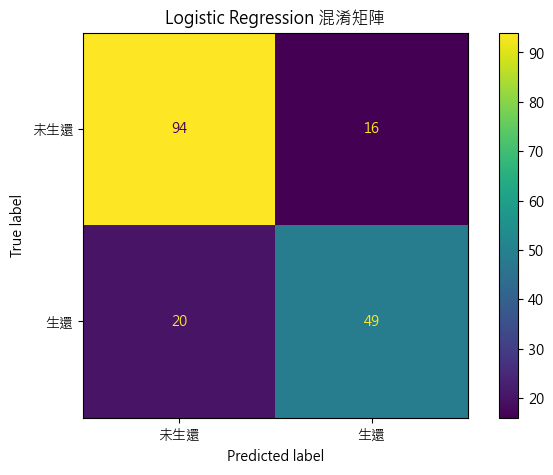

In [29]:
# ============================================================
# 使用混淆矩陣視覺化分類結果
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["未生還", "生還"]
)

plt.title("Logistic Regression 混淆矩陣")
plt.show()

### 作業問題 9

請回答：

1. 測試集 Accuracy 是多少？
2. 從混淆矩陣看，模型比較常把哪一類預測錯？
3. 如果資料類別非常不平均，只看 Accuracy 可能有什麼問題？

## 13. K-fold 交叉驗證

一次訓練集與測試集切分可能受到隨機切分影響。

K-fold 交叉驗證會把資料分成 K 份，每次用其中 1 份當驗證集，其餘 K-1 份當訓練集。

分類任務常用 `StratifiedKFold`，讓每一折的類別比例盡量接近原始資料。

> 教學簡化說明：本作業已經完成編碼與標準化後再做交叉驗證。正式研究中，資料前處理應該放在每一折的訓練資料內重新 fit；但本作業不使用 Pipeline，因此先用簡化版本理解交叉驗證概念。

In [30]:
# ============================================================
# 使用 StratifiedKFold 做 5-fold 交叉驗證
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_model = LogisticRegression(max_iter=1000, random_state=42)

cv_scores = cross_val_score(
    estimator=cv_model,
    X=X_train_scaled,
    y=y_train,
    cv=cv,
    scoring="accuracy"
)

# 顯示每一折的 Accuracy
fold_number = 1
for score in cv_scores:
    print("第", fold_number, "折 Accuracy：", score)
    fold_number = fold_number + 1

print("\n平均 Accuracy：", cv_scores.mean())
print("Accuracy 標準差：", cv_scores.std())

第 1 折 Accuracy： 0.7902097902097902
第 2 折 Accuracy： 0.7832167832167832
第 3 折 Accuracy： 0.8098591549295775
第 4 折 Accuracy： 0.7746478873239436
第 5 折 Accuracy： 0.823943661971831

平均 Accuracy： 0.796375455530385
Accuracy 標準差： 0.018028141678796877


### 作業問題 10

請回答：

1. 5 折交叉驗證的平均 Accuracy 是多少？
2. 每一折的分數是否差很多？
3. 交叉驗證為什麼比只看一次切分更穩定？

# 14. 特徵選擇：低變異過濾

低變異特徵是指幾乎所有資料都相同的特徵。

如果一個特徵變化很小，通常能提供的資訊也比較少。

本節使用 `VarianceThreshold` 示範低變異過濾。

注意：`VarianceThreshold` 只看特徵本身，不會參考目標變數 `Survived`。

In [31]:
# ============================================================
# VarianceThreshold：低變異過濾
# ============================================================

variance_selector = VarianceThreshold(threshold=0.01)
variance_selector.fit(X_train_scaled)

support_mask = variance_selector.get_support()

selected_by_variance = []
removed_by_variance = []

for i in range(len(support_mask)):
    column_name = X_train_scaled.columns[i]
    if support_mask[i] == True:
        selected_by_variance.append(column_name)
    else:
        removed_by_variance.append(column_name)

print("保留的特徵：")
print(selected_by_variance)

print("\n移除的特徵：")
print(removed_by_variance)

保留的特徵：
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare_Capped', 'HasCabin', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

移除的特徵：
[]


In [32]:
# 顯示每個特徵的變異數
variance_table = pd.DataFrame()
variance_table["feature"] = X_train_scaled.columns
variance_table["variance"] = X_train_scaled.var().values
variance_table = variance_table.sort_values("variance", ascending=False)
variance_table

,feature,variance
0,Pclass,1.001406
1,Age,1.001406
4,Fare_Capped,1.001406
5,HasCabin,1.001406
2,SibSp,1.001406
3,Parch,1.001406
6,Sex_female,0.229395
7,Sex_male,0.229395
10,Embarked_S,0.198510
8,Embarked_C,0.157333


### 作業問題 11

請回答：

1. 哪些特徵的變異數比較小？
2. 低變異特徵一定沒有用嗎？為什麼？
3. `VarianceThreshold` 有沒有使用到 `Survived`？

## 15. 特徵之間的相關性

如果兩個特徵高度相關，可能代表它們提供了很相似的資訊。

本節使用 Pearson 相關係數觀察數值特徵之間的關係。

原教材也提到 Spearman、Kendall 等級相關，但本作業只示範 Pearson。

In [33]:
# ============================================================
# 計算數值特徵之間的 Pearson 相關係數
# ============================================================

corr_matrix = X_train_scaled[numeric_model_columns].corr()
corr_matrix

,Pclass,Age,SibSp,Parch,Fare_Capped,HasCabin
Pclass,1.000000,-0.322509,0.097900,0.040467,-0.707654,-0.712738
Age,-0.322509,1.000000,-0.238496,-0.160241,0.130720,0.210500
SibSp,0.097900,-0.238496,1.000000,0.392269,0.302568,-0.056749
Parch,0.040467,-0.160241,0.392269,1.000000,0.269434,0.022209
Fare_Capped,-0.707654,0.130720,0.302568,0.269434,1.000000,0.594026
HasCabin,-0.712738,0.210500,-0.056749,0.022209,0.594026,1.000000


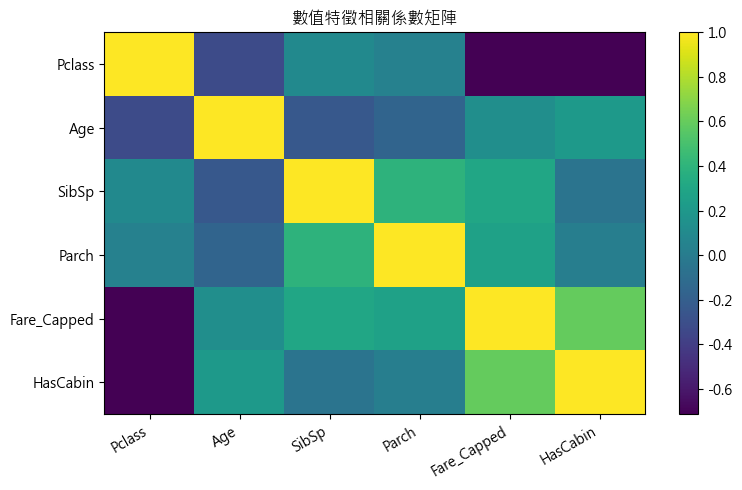

In [34]:
# ============================================================
# 視覺化相關係數矩陣
# ============================================================

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=30, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("數值特徵相關係數矩陣")
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# 找出高度相關的特徵組合
# ============================================================

threshold = 0.70
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        feature_1 = corr_matrix.columns[i]
        feature_2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        abs_corr_value = abs(corr_value)

        if abs_corr_value >= threshold:
            high_corr_pairs.append([feature_1, feature_2, corr_value])

high_corr_table = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "correlation"]
)

high_corr_table

,feature_1,feature_2,correlation
0,Pclass,Fare_Capped,-0.707654
1,Pclass,HasCabin,-0.712738


### 作業問題 12

請回答：

1. 哪兩個數值特徵相關性最高？
2. 是否有相關係數絕對值大於 0.70 的特徵組合？
3. 高相關特徵一定要刪除嗎？為什麼？

## 16. 特徵與目標變數的關係：ANOVA F-test

特徵選擇除了看特徵本身，也可以看特徵和目標變數之間的關係。

原教材整理了不同變數型態可以使用的方法：

| 變數類型 | 常見方法 |
|---|---|
| 數值型特徵 vs 數值型目標 | Pearson 相關係數 |
| 類別型特徵 vs 類別型目標 | Chi-square test |
| 數值型特徵 vs 類別型目標 | ANOVA F-test |
| 非線性依賴關係 | Mutual Information |

本作業的目標 `Survived` 是類別型，這裡選擇示範 **數值型特徵 vs 類別型目標** 的 ANOVA F-test。

In [36]:
# ============================================================
# 使用 ANOVA F-test 檢查數值特徵與 Survived 的關係
# ============================================================

X_numeric_for_anova = X_train_scaled[numeric_model_columns]

f_values, p_values = f_classif(X_numeric_for_anova, y_train)

anova_table = pd.DataFrame()
anova_table["feature"] = numeric_model_columns
anova_table["F_value"] = f_values
anova_table["p_value"] = p_values
anova_table = anova_table.sort_values("F_value", ascending=False)

anova_table

,feature,F_value,p_value
5,HasCabin,99.462219,5.177302e-22
0,Pclass,97.835853,1.064770e-21
4,Fare_Capped,96.321478,2.086688e-21
3,Parch,5.066904,2.469201e-02
1,Age,3.630391,5.713717e-02
2,SibSp,0.484537,4.866020e-01


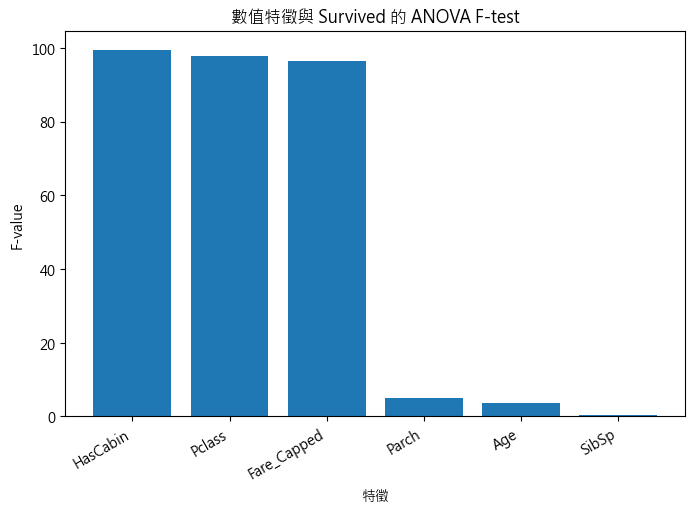

In [37]:
# ============================================================
# 視覺化 ANOVA F-value
# ============================================================

plt.bar(anova_table["feature"], anova_table["F_value"])
plt.xlabel("特徵")
plt.ylabel("F-value")
plt.title("數值特徵與 Survived 的 ANOVA F-test")
plt.xticks(rotation=30, ha="right")
plt.show()

### 作業問題 13

請回答：

1. 哪個數值特徵的 F-value 最大？
2. F-value 越大通常代表什麼？
3. p-value 小於 0.05 時，通常可以如何解釋？

## 17. 特徵重要性：Permutation Importance

Permutation Importance 的概念是：

1. 先訓練好模型
2. 一次打亂一個特徵
3. 觀察模型表現下降多少
4. 如果打亂某個特徵後 Accuracy 明顯下降，代表模型很依賴該特徵

原教材中還有 RFECV 等包裹式特徵選擇方法。本作業為了簡化，只使用 Permutation Importance。

In [38]:
# ============================================================
# 計算 Permutation Importance
# ============================================================

perm_result = permutation_importance(
    model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

importance = perm_result.importances_mean
importance_std = perm_result.importances_std

importance_table = pd.DataFrame()
importance_table["feature"] = X_test_scaled.columns
importance_table["importance_mean"] = importance
importance_table["importance_std"] = importance_std
importance_table = importance_table.sort_values("importance_mean", ascending=False)

importance_table

,feature,importance_mean,importance_std
7,Sex_male,0.051955,0.018197
6,Sex_female,0.050279,0.017842
1,Age,0.031285,0.018051
2,SibSp,0.030726,0.011517
0,Pclass,0.015642,0.012442
3,Parch,0.007821,0.007578
5,HasCabin,0.003911,0.011187
4,Fare_Capped,0.002235,0.014611
8,Embarked_C,0.000000,0.000000
9,Embarked_Q,-0.004469,0.004181


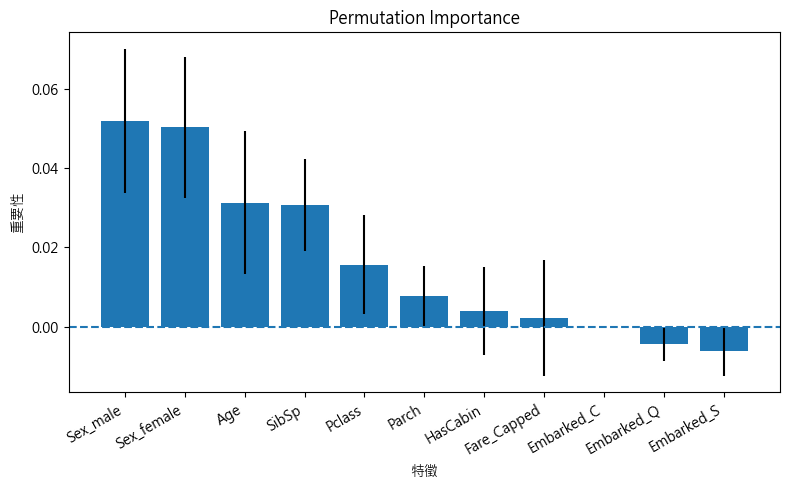

In [39]:
# ============================================================
# 視覺化 Permutation Importance
# ============================================================

sorted_index = np.argsort(importance)[::-1]

sorted_feature_names = []
sorted_importance = []
sorted_std = []

for i in sorted_index:
    sorted_feature_names.append(X_test_scaled.columns[i])
    sorted_importance.append(importance[i])
    sorted_std.append(importance_std[i])

plt.bar(
    sorted_feature_names,
    sorted_importance,
    yerr=sorted_std
)
plt.xlabel("特徵")
plt.ylabel("重要性")
plt.title("Permutation Importance")
plt.xticks(rotation=30, ha="right")
plt.axhline(y=0, linestyle="--")
plt.tight_layout()
plt.show()

### 作業問題 14

請回答：

1. 哪個特徵的重要性最高？
2. 如果某個特徵的重要性接近 0，代表什麼意思？
3. Permutation Importance 和 ANOVA F-test 的差異是什麼？

## 18. 使用模型預測新乘客

最後，建立一筆新乘客資料，練習如何使用前面建立的模型做預測。

注意：新資料必須經過和訓練資料相同的前處理流程：

1. 建立相同欄位
2. One-Hot Encoding
3. 欄位順序對齊訓練資料
4. 使用訓練資料的 `scaler` 做 `transform()`
5. 丟進模型預測

In [40]:
# ============================================================
# 建立一筆新乘客資料
# ============================================================

new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": ["male"],
    "Age": [22],
    "SibSp": [1],
    "Parch": [0],
    "Fare_Capped": [7.25],
    "Embarked": ["S"],
    "HasCabin": [0]
})

# One-Hot Encoding
new_passenger_encoded = pd.get_dummies(
    new_passenger,
    columns=["Sex", "Embarked"],
    dtype=int
)

# 對齊訓練資料欄位
# 若新資料缺少某些欄位，補 0
new_passenger_encoded = new_passenger_encoded.reindex(
    columns=X_train_scaled.columns,
    fill_value=0
)

# 複製一份來標準化
new_passenger_scaled = new_passenger_encoded.copy()

# 使用訓練資料的 scaler 轉換新資料
new_passenger_scaled[numeric_model_columns] = scaler.transform(
    new_passenger_encoded[numeric_model_columns]
)

# 預測類別
new_prediction = model.predict(new_passenger_scaled)

# 預測生還機率
new_probability = model.predict_proba(new_passenger_scaled)

print("預測結果：", new_prediction[0])
print("未生還機率：", new_probability[0][0])
print("生還機率：", new_probability[0][1])

預測結果： 0
未生還機率： 0.9132829181982711
生還機率： 0.08671708180172884


### 作業問題 15

請修改 `new_passenger`，至少測試 3 位不同乘客：

1. 一位一等艙女性乘客
2. 一位三等艙男性乘客
3. 一位年齡較小的兒童乘客

請觀察預測結果與生還機率是否有差異，並說明你認為可能的原因。

# 19. 作業總結

本作業完成了一個簡化版的分類建模流程：

1. 讀取 Titanic 資料
2. 檢查資料型態與遺漏值
3. 使用 `SimpleImputer` 填補遺漏值
4. 使用 `StandardScaler` 標準化數值特徵
5. 使用 `pd.get_dummies()` 編碼類別特徵
6. 使用 IQR 法檢查並處理離群值
7. 使用 `train_test_split()` 切割訓練集與測試集
8. 使用 Logistic Regression 建立分類模型
9. 使用 Accuracy 與混淆矩陣評估模型
10. 使用 K-fold 交叉驗證檢查模型穩定性
11. 使用低變異過濾、相關係數、ANOVA F-test、Permutation Importance 觀察特徵

---

## 繳交內容

請繳交：

1. 執行完成後的 Notebook
2. 作業問題 1 到作業問題 15 的回答
3. 你自己測試的 3 位新乘客預測結果